In [42]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt,log10
from astropy.table import Table
from astropy.table import unique
import os
import ctadata
from astropy.io import ascii
from scipy import stats


In [2]:
data_folder = "./LST_data/"
DL3_folder = "/pnfs/cta.cscs.ch/lst/DL3/"
run_catalog=ascii.read(data_folder + 'LST_source_catalog.ecsv')

In [3]:
Name='Mrk501'
gheff='gheff0.9'
Zdcut=30

coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)
ra_obj,dec_obj

(253.467569516792, 39.760169132056)

In [4]:
#Ebins=np.logspace(log10(0.05),log10(50),16)
Ebins=np.array([0.5, 1.5, 4.0, 10.0, 25.0])
Emins=Ebins[:-1]
Emaxs=Ebins[1:]
Emeans=sqrt(Emins*Emaxs)
dE=Emaxs-Emins
Nebins=len(Emeans)

th2bins=np.linspace(0.0, 0.13, 20)
th2=(th2bins[1:]+th2bins[:-1])/2.
Nth=len(th2)


In [5]:
runlist=np.load(data_folder+'good_runs_'+Name+'_Zd_30.0.npy')
countermax=1000
counter=0

flist=[]

cts_s=np.zeros((Nebins,Nth))
cts_b1=np.zeros((Nebins,Nth))
cts_effarea_corr = np.zeros((Nebins,Nth))
cts_effarea_corr_err = np.zeros((Nebins,Nth))

tstart=np.array([])
tstop=np.array([])
texpos=np.array([])

for ind in range(len(runlist)):
    r=runlist[ind]
    for i in range(len(run_catalog)):
        run=run_catalog[i]['Run ID']
        if(run==r):
            date=run_catalog[i]['Date directory'].replace('-','')
            vers=ctadata.list_dir(DL3_folder+date)
            for ver in vers:
                if(ver[0]=='v'):
                    tailcuts=ctadata.list_dir(DL3_folder+date+'/'+ver)
                    for tailcut in (tailcuts):
                        nsbs=ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut)
                        for nsb in nsbs:
                            versions=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb))
                            for version in versions:
                                tags=ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std')
                                for tag in tags:
                                    src_dependences=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag))
                                    for src_dep in src_dependences:
                                        point_or_full=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep))
                                        for p_f in point_or_full:
                                            wobbles=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f))
                                            for wob in wobbles:
                                                gheffs=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob))        
                                                for gh in gheffs:
                                                    if(gheff in gh):
                                                        irfs=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh))
                                                        for irf in irfs:
                                                            files=(ctadata.list_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf))
                                                            if(run<10000):
                                                                fname='dl3_LST-1.Run0'+str(run)+'.fits'
                                                            else:
                                                                fname='dl3_LST-1.Run'+str(run)+'.fits'
                                                            if(fname in files):
                                                                flist.append(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                f=(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                counter+=1
                                                                ctadata.fetch_and_save_file_or_dir(DL3_folder+date+'/'+ver+'/'+tailcut+'/'+nsb+'/'+version+'/std/'+tag+'/'+src_dep+'/'+p_f+'/'+wob+'/'+gh+'/'+irf+'/'+fname)
                                                                hdul=fits.open(fname)
                                                                header=hdul[1].header
                                                                dat=header['DATE-OBS']
                                                                texpos=np.concatenate((texpos,[header['LIVETIME']]))
                                                                print(ind,date,fname,sum(texpos))
        
                                                                ra_pnt=header['RA_PNT']
                                                                dec_pnt=header['DEC_PNT'] 
                                                                dra=ra_obj-ra_pnt
                                                                ddec=dec_obj-dec_pnt
        
                                                                ra_bkg1=ra_pnt-dra
                                                                dec_bkg1=dec_pnt-ddec
                                                                coords_bkg1=SkyCoord(ra_bkg1,dec_bkg1,unit='degree')
                    
                                                                events=hdul['EVENTS'].data
                                                                coords=SkyCoord(events['RA'],events['DEC'],unit='degree')
        
                                                                seps=coords.separation(coords_obj).deg
                                                                seps_b1=coords_bkg1.separation(coords).deg
        
                                                                energies=events['ENERGY']
                                                                effarea_hdu=hdul['EFFECTIVE AREA'].data
                                                                effarea = effarea_hdu["EFFAREA"]*100**2 # from m**2 cm**2
                                                                effareas_ebins_mean = np.sqrt(effarea_hdu["ENERG_LO"]*effarea_hdu["ENERG_HI"])
                                                                i=0
                                                                for i in range(Nebins):
                                                                    m=(energies>Emins[i])*(energies<Emaxs[i])*(seps<0.4) 
                                                                    h=np.histogram(seps[m]**2,bins=th2bins)
                                                                    cts_s[i]+=h[0]
                                                                    m=(energies>Emins[i])*(energies<Emaxs[i])*(seps_b1<0.4) 
                                                                    h_b1=np.histogram(seps_b1[m]**2,bins=th2bins)
                                                                    cts_b1[i]+=h_b1[0]
                                                                    
                                                                    diff = h[0] - h_b1[0]
                                                                    diff_err = np.sqrt(h[0] + h_b1[0])
                                                                    effarea_usable_ind = np.argmin(np.abs(Emeans[i]*np.ones(effareas_ebins_mean.shape[0]) - effareas_ebins_mean))
                                                                    cts_effarea_corr[i] += diff/effarea[0][0][effarea_usable_ind]
                                                                    cts_effarea_corr_err[i] += (diff_err / effarea[0][0][effarea_usable_ind])**2
                                                                
                                                                if counter == countermax:
                                                                    raise Exception("Finito")
                                                                os.remove(fname)


0 20210317 dl3_LST-1.Run04139.fits 1130.0273713094493
1 20210317 dl3_LST-1.Run04140.fits 2285.6314455998217
2 20210320 dl3_LST-1.Run04191.fits 3376.4757995005757
3 20210320 dl3_LST-1.Run04192.fits 4434.079311787033
4 20210320 dl3_LST-1.Run04193.fits 5445.953479205643
5 20210320 dl3_LST-1.Run04194.fits 5913.98433922381
7 20210321 dl3_LST-1.Run04212.fits 6765.585069056559
8 20210321 dl3_LST-1.Run04213.fits 7618.715000827843
9 20210321 dl3_LST-1.Run04214.fits 8464.551386545376
10 20210321 dl3_LST-1.Run04215.fits 9316.815538434756
11 20210417 dl3_LST-1.Run04473.fits 9889.338052577488
12 20210417 dl3_LST-1.Run04474.fits 11021.659603779932
13 20210417 dl3_LST-1.Run04475.fits 12159.294082798497
14 20210417 dl3_LST-1.Run04476.fits 12730.879858123504
15 20210418 dl3_LST-1.Run04483.fits 13590.69189886632
16 20210418 dl3_LST-1.Run04484.fits 14729.193451340216
17 20210419 dl3_LST-1.Run04496.fits 15751.168308897442
18 20210419 dl3_LST-1.Run04497.fits 16774.027483414444
19 20210419 dl3_LST-1.Run0449

In [7]:
cts_effarea_corr_err = np.sqrt(cts_effarea_corr_err)

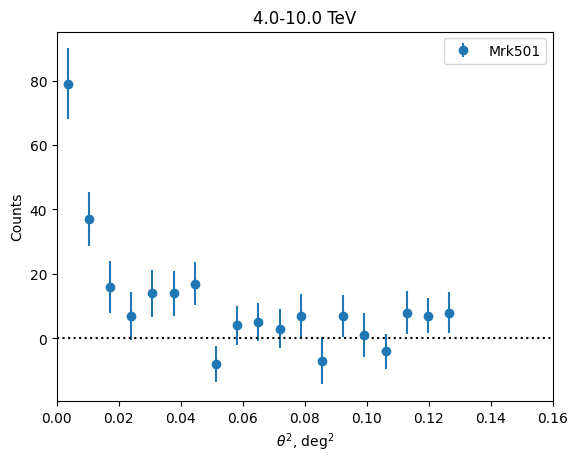

In [8]:
i=2
s_err=sqrt(cts_s[i]+cts_b1[i])
s=cts_s[i]-cts_b1[i]
plt.errorbar(th2,s,s_err,linestyle='none',marker='o',label=Name)
plt.axhline(0,color='black',linestyle='dotted')
plt.xlim(0,0.16)
plt.title(str(round(Emins[i],3))+'-'+str(round(Emaxs[i],3))+' TeV')
plt.xlabel(r'$\theta^2$, deg$^2$')
plt.ylabel('Counts')
plt.legend(loc='upper right')
#plt.savefig('th2_'+Name+'_'+str(round(Emins[i],3))+'-'+str(round(Emaxs[i],3))+'TeV.png',bbox_inches='tight')

In [9]:
#fname = 'cts_'+Name+'_'+gheff
#np.save(fname,(cts_s,cts_b1))
#!mv "{fname}.npy" "{data_folder}"

In [33]:
fluxes = Emeans**2*cts_effarea_corr.T/np.sum(texpos)/dE
fluxes_err = Emeans**2*cts_effarea_corr_err.T/np.sum(texpos)/dE
fluxes=fluxes.T
fluxes_err=fluxes_err.T
fluxes.shape

(4, 19)

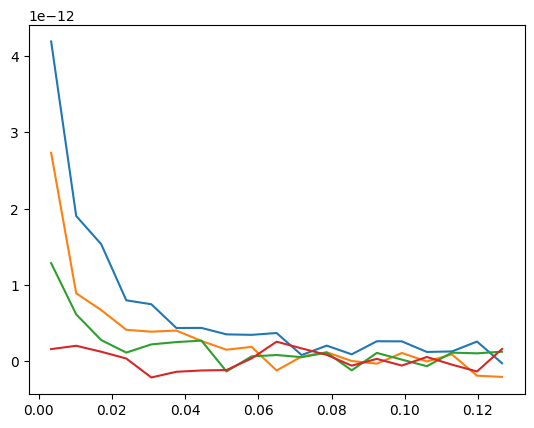

In [11]:
for flux in fluxes:
    plt.plot(th2, flux)

In [12]:
korochkin_dir = "paper_extr_data/"
def extr_data_from_csv(filepath):
    tot_datapoints = 19
    data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    if data.size == 0:
        return np.zeros(tot_datapoints)

    if data.ndim == 1:
        values = data
    else:
        values = data[:, 1] if data.shape[1] > 1 else data[:, 0]

    if len(values) < tot_datapoints:
        values = np.append(values, np.zeros(tot_datapoints - len(values)))

    return values


paper_src_0d5_1d5 = extr_data_from_csv(f"{korochkin_dir}corchkin_0d5_1d5TeV_blk_line.csv")
paper_src_1d5_4 = extr_data_from_csv(f"{korochkin_dir}corchkin_1d5_4TeV_blk_line.csv")
paper_src_4_10 = extr_data_from_csv(f"{korochkin_dir}corchkin_4_10TeV_blk_line.csv")

paper_red_0d5_1d5 = extr_data_from_csv(f"{korochkin_dir}corchkin_0d5_1d5TeV_red_line.csv")
paper_green_0d5_1d5 = extr_data_from_csv(f"{korochkin_dir}corchkin_0d5_1d5TeV_gre_line.csv")
paper_blue_0d5_1d5 = extr_data_from_csv(f"{korochkin_dir}corchkin_0d5_1d5TeV_blu_line.csv")

paper_red_1d5_4 = extr_data_from_csv(f"{korochkin_dir}corchkin_1d5_4TeV_red_line.csv")
paper_green_1d5_4 = extr_data_from_csv(f"{korochkin_dir}corchkin_1d5_4TeV_gre_line.csv")
paper_blue_1d5_4 = extr_data_from_csv(f"{korochkin_dir}corchkin_1d5_4TeV_blu_line.csv")

paper_red_4_10 = extr_data_from_csv(f"{korochkin_dir}corchkin_4_10TeV_red_line.csv")
paper_green_4_10 = extr_data_from_csv(f"{korochkin_dir}corchkin_4_10TeV_gre_line.csv")
paper_blue_4_10 = extr_data_from_csv(f"{korochkin_dir}corchkin_4_10TeV_blu_line.csv")

paper_bkg_0d5_1d5 = 4e-14
paper_bkg_1d5_4 = 7.5e-15
paper_bkg_4_10 = 1.5e-15

paper_data = {
    "0.5-1.5 TeV": (
        paper_src_0d5_1d5,
        paper_red_0d5_1d5,
        paper_blue_0d5_1d5,
        paper_green_0d5_1d5,
        paper_bkg_0d5_1d5,
    ),
    "1.5-4 TeV": (
        paper_src_1d5_4,
        paper_red_1d5_4,
        paper_blue_1d5_4,
        paper_green_1d5_4,
        paper_bkg_1d5_4,
    ),
    "4-10 TeV": (
        paper_src_4_10,
        paper_red_4_10,
        paper_blue_4_10,
        paper_green_4_10,
        paper_bkg_4_10,
    ),
}

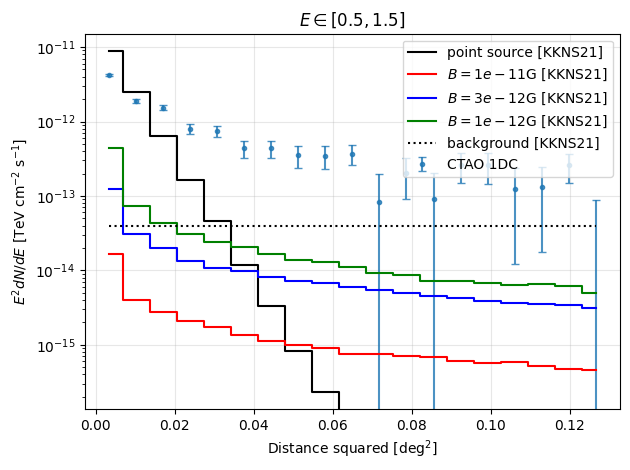

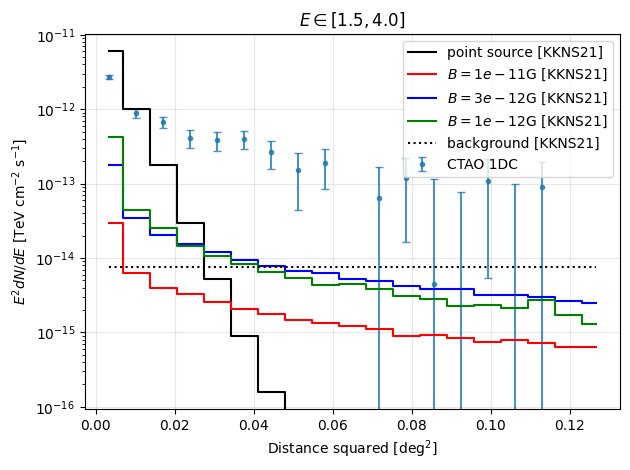

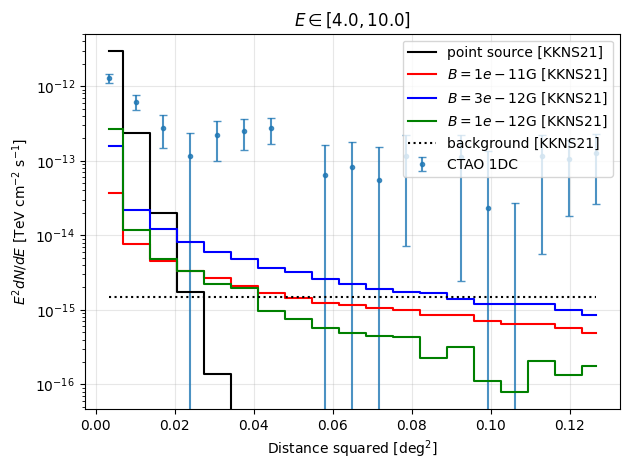

In [13]:
for i, (dataset_name, dataset_data) in enumerate(paper_data.items()):

    E_min, E_max = map(float, dataset_name.split(" ")[0].split("-"))
    sed_values = fluxes[i]
    sed_errors = fluxes_err[i]
    angle_bin_centers = th2
    plt.errorbar(
        angle_bin_centers,
        sed_values,
        yerr=np.abs(sed_errors),
        fmt=".",
        markersize=6,
        linewidth=1.5,
        capsize=3,
        alpha=0.8,
        label="CTAO 1DC",
    )
    plt.step(th2, dataset_data[0], "k", label="point source [KKNS21]",where="mid",)

    plt.step(
        angle_bin_centers,
        dataset_data[1],
        "r",
        label=rf"$B=1e-11$G [KKNS21]",
        where="mid",
    )
    plt.step(
        angle_bin_centers,
        dataset_data[2],
        "b",
        label=rf"$B=3e-12$G [KKNS21]",
        where="mid",
    )
    plt.step(
        angle_bin_centers,
        dataset_data[3],
        "g",
        label=rf"$B=1e-12$G [KKNS21]",
        where="mid",
    )
    plt.plot(
        angle_bin_centers,
        dataset_data[4] * angle_bin_centers**0,
        "k:",
        label="background [KKNS21]",
    )

    plt.yscale("log")
    plt.xlabel(r"Distance squared [deg$^2$]")
    plt.ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
    plt.title(rf"$E\in[{E_min}, {E_max}]$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [34]:
def gauss_src(sigma):
    return np.exp(-angle_bin_centers / (2 * sigma**2))


def fit_model(angle_centers, bkg, src_norm, src_sigma, bkg_norm):
    src = src_norm * gauss_src(src_sigma)
    bkg = bkg_norm * bkg
    return src + bkg


def fit_model_ext(
    ext_data, angle_centers, bkg, src_norm, src_sigma, bkg_norm, ext_norm
):
    src = src_norm * gauss_src(src_sigma)
    bkg_ = bkg_norm * bkg
    ext = ext_norm * ext_data
    return src + bkg_ + ext


def fit_model_ext_double(
    ext_data1,
    ext_data2,
    angle_centers,
    bkg1,
    bkg2,
    src_norm1,
    src_norm2,
    src_sigma1,
    src_sigma2,
    bkg_norm1,
    bkg_norm2,
    ext_norm,
):
    src1 = src_norm1 * gauss_src(src_sigma1)
    bkg1_ = bkg_norm1 * bkg1
    ext1 = ext_norm * ext_data1
    model1 = src1 + bkg1_ + ext1

    src2 = src_norm2 * gauss_src(src_sigma2)
    bkg2_ = bkg_norm2 * bkg2
    ext2 = ext_norm * ext_data2
    model2 = src2 + bkg2_ + ext2

    return np.concatenate([model1, model2])

In [45]:
from scipy.optimize import curve_fit

for i, (dataset_name, dataset_data) in enumerate(paper_data.items()):
    ext_data = dataset_data[3]  # green
    bkg = dataset_data[4]

    E_min, E_max = map(float, dataset_name.split(" ")[0].split("-"))
    sed_values = np.abs(fluxes[i])
    sed_errors = np.abs(fluxes_err[i])
    angle_bin_centers = th2

    init_guess = [1.0, 0.1, 1.0]

    def fit_no_ext(angle_centers, src_norm, src_sigma, bkg_norm):
        return fit_model(angle_centers, bkg, src_norm, src_sigma, bkg_norm)

    popt, pcov = curve_fit(
        fit_no_ext,
        angle_bin_centers,
        sed_values,
        sigma=sed_errors,
        p0=init_guess,
        absolute_sigma=True,
    )
    src_norm_fit, src_sigma_fit, bkg_norm_fit = popt
    src_norm_err, src_sigma_err, bkg_norm_err = np.sqrt(np.diag(pcov))
    fit_no_ext_v = fit_no_ext(angle_bin_centers, *popt)

    print(f"No extended fit {dataset_name}:")
    print(rf"Background normalization: {bkg_norm_fit:.3f} $\pm$ {bkg_norm_err:.3f}")
    print(rf"Source normalization: {src_norm_fit} $\pm$ {src_norm_err}")
    print(rf"Src sigma: {src_sigma_fit:.3f} $\pm$ {src_sigma_err:.3f}")
    print("\n")

    init_guess = [1.0, 0.1, 1.0, 1.0]

    def fit_ext(angle_centers, src_norm, src_sigma, bkg_norm, ext_norm):
        return fit_model_ext(ext_data, angle_centers, bkg, src_norm, src_sigma, bkg_norm, ext_norm)

    popt, pcov = curve_fit(
        fit_ext,
        angle_bin_centers,
        sed_values,
        sigma=sed_errors,
        p0=init_guess,
        absolute_sigma=True,
    )
    src_norm_fit, src_sigma_fit, bkg_norm_fit, ext_norm_fit = popt
    src_norm_err, src_sigma_err, bkg_norm_err, ext_norm_err = np.sqrt(np.diag(pcov))
    fit_ext_v = fit_ext(angle_bin_centers, *popt)

    print(f"Extended fit (green) {dataset_name}:")
    print(rf"Background normalization: {bkg_norm_fit:.3f} $\pm$ {bkg_norm_err:.3f}")
    print(rf"Source normalization: {src_norm_fit} $\pm$ {src_norm_err}")
    print(rf"Extended normalization: {ext_norm_fit} $\pm$ {ext_norm_err}")
    print(rf"Src sigma: {src_sigma_fit:.3f} $\pm$ {src_sigma_err:.3f}")
    print("\n")

    chi2_no_ext = np.sum(((sed_values - fit_no_ext_v) / sed_errors)**2)
    chi2_ext = np.sum(((sed_values - fit_ext_v) / sed_errors)**2)
    dof_no_ext = len(sed_values) - 3
    dof_ext = len(sed_values) - 4
    delta_chi2 = chi2_no_ext - chi2_ext
    delta_dof = dof_no_ext - dof_ext
    p_value = stats.chi2.sf(delta_chi2, delta_dof)
    f_stat = (delta_chi2 / delta_dof) / (chi2_ext / dof_ext)
    p_value_f = stats.f.sf(f_stat, delta_dof, dof_ext)

    print(f"p-value: {p_value}")
    print("\n")

No extended fit 0.5-1.5 TeV:
Background normalization: 5.379 $\pm$ 0.817
Source normalization: 5.103782909576713e-12 $\pm$ 2.4697785407802465e-13
Src sigma: 0.076 $\pm$ 0.003


Extended fit (green) 0.5-1.5 TeV:
Background normalization: 3.278 $\pm$ 1.082
Source normalization: 2.7365930241451536e-12 $\pm$ 4.631596942009127e-13
Extended normalization: 4.154880685723745 $\pm$ 0.9024043193003767
Src sigma: 0.094 $\pm$ 0.007


p-value: 0.00013871413080692783


No extended fit 1.5-4 TeV:
Background normalization: 19.242 $\pm$ 3.769
Source normalization: 3.785357204993102e-12 $\pm$ 3.6730304890486543e-13
Src sigma: 0.063 $\pm$ 0.004


Extended fit (green) 1.5-4 TeV:
Background normalization: 9.388 $\pm$ 6.103
Source normalization: 1.0297383488187952e-12 $\pm$ 3.155596207806888e-13
Extended normalization: 4.210452186057862 $\pm$ 0.7468950733039954
Src sigma: 0.105 $\pm$ 0.019


p-value: 0.00017771474729124252


No extended fit 4-10 TeV:
Background normalization: 73.449 $\pm$ 18.071
Source norm